# Klasyfikacja jakości wina

Kamil Kluska

Marek Gozdalski

In [264]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset zawiera informacje o składzie chemicznym różnych odmian czerwonego wina wraz z jego oceną jakości.

1.  **Fixed acidity** – Kwasowość stała (związana z kwasami, które naturalnie występują w winogronach i nie odparowują).
2.  **Volatile acidity** – Kwasowość lotna (jej nadmiar nadaje winu nieprzyjemny, octowy posmak).
3.  **Citric acid** – Kwas cytrynowy.
4.  **Residual sugar** – Cukier resztkowy (ilość cukru, która pozostaje w winie po zakończeniu fermentacji).
5.  **Chlorides** – Chlorki (określają poziom soli w winie).
6.  **Free sulfur dioxide** – Wolny dwutlenek siarki.
7.  **Total sulfur dioxide** – Całkowity dwutlenek siarki.
8.  **Density** – Gęstość (zależy od zawartości alkoholu i cukru).
9.  **pH** – Mierzy kwasowość wina (większość win na świecie mieści się w przedziale 3.0 – 4.0).
10. **Sulphates** – Siarczany (dodatki, które mogą zwiększać poziom wolnego dwutlenku siarki).
11. **Alcohol** – Zawartość alkoholu w procentach.
12. **Quality** - Ocena jakości wina (skala od 3 do 8, gdzie 3 oznacza najgorsze, a 8 najlepsze wino).
13. **Quality_bin** - Binarna ocena jakości wina. 0 - słabe (quality<7), 1 - dobre (quality>=7).

# EDA

In [265]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys

# Podajesz ścieżkę do FOLDERU, w którym leży plik .py
sciezka_do_folderu = '/content/drive/MyDrive/Red-Wine-Classification'
sys.path.append(sciezka_do_folderu)



from src.helpers import create_percentage_plot, quality_based_plot

In [266]:
df = pd.read_csv("/content/drive/MyDrive/Red-Wine-Classification/data/winequality-red.csv", sep=";")

In [267]:
# Dodanie kolumny do binaryzacji
df['quality_bin'] = np.astype((df['quality'] >= 7).to_numpy(), np.int8)

## Ogólne informacje

In [268]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [269]:
df.shape

(1599, 13)

In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_bin           1599 non-null   int8   
dtypes: float64(11), int64(1), int8(1)
memory usage: 151.6 KB


In [271]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Poniżej widać, że nie mamy żadnych brakujących danych.

In [272]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


<Axes: >

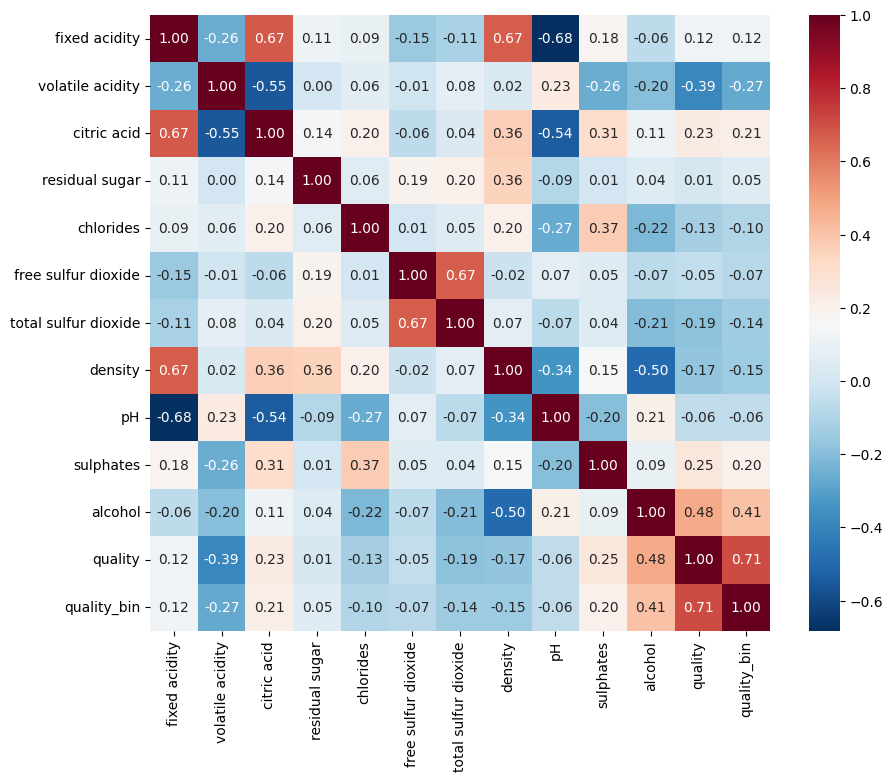

In [273]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r')

## quality

In [274]:
df['quality'].sort_values().unique()

array([3, 4, 5, 6, 7, 8])

Dane są drastycznie niezbalansowane.

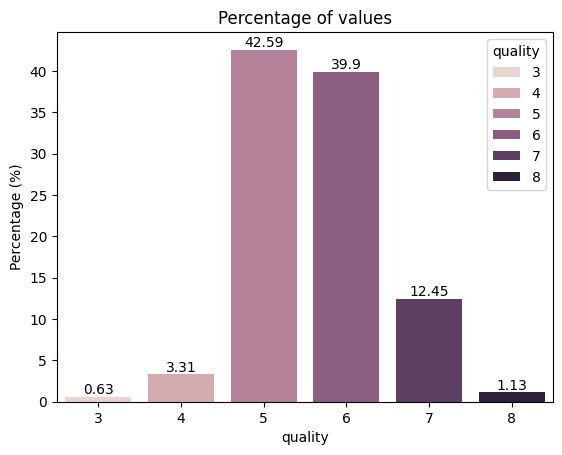

In [275]:
create_percentage_plot(df['quality'], bar_label=True)

<Axes: >

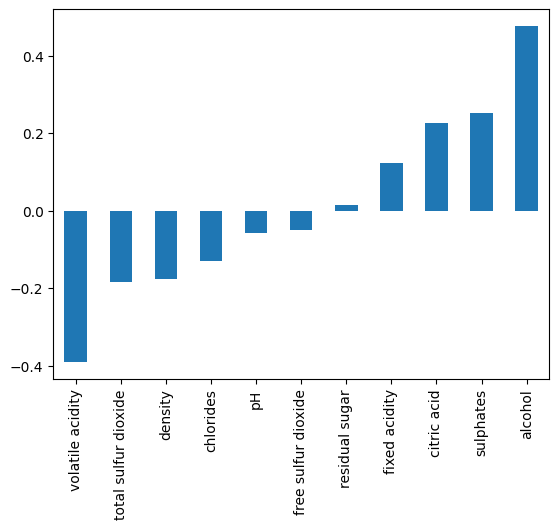

In [276]:
df.drop(['quality_bin'], axis=1).corr()['quality'][:-1].sort_values().plot(kind='bar')

Text(0.5, 1.0, 'Outliers')

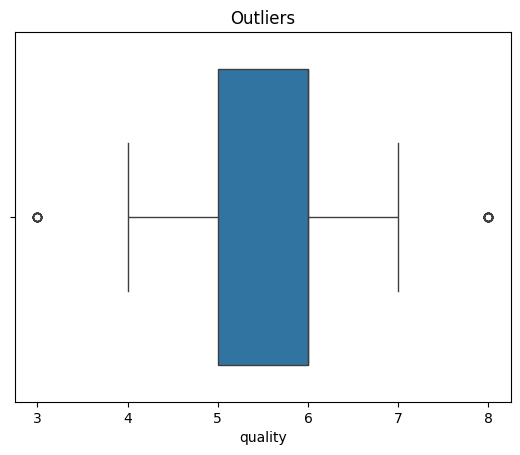

In [277]:
sns.boxplot(df, x='quality')
plt.title("Outliers")

## quality_bin

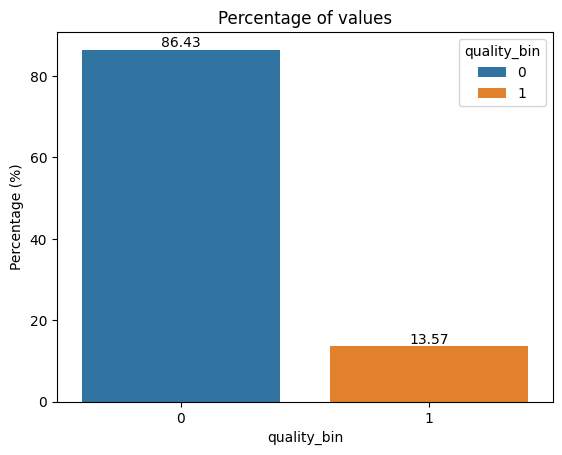

In [278]:
create_percentage_plot(df['quality_bin'], bar_label=True)

<Axes: >

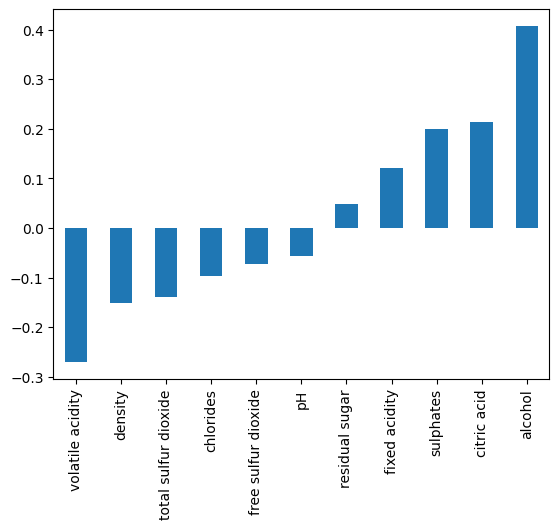

In [279]:
df.drop(['quality'], axis=1).corr()['quality_bin'][:-1].sort_values().plot(kind='bar')

## fixed acidity

Brak trendu dla tej cechy.

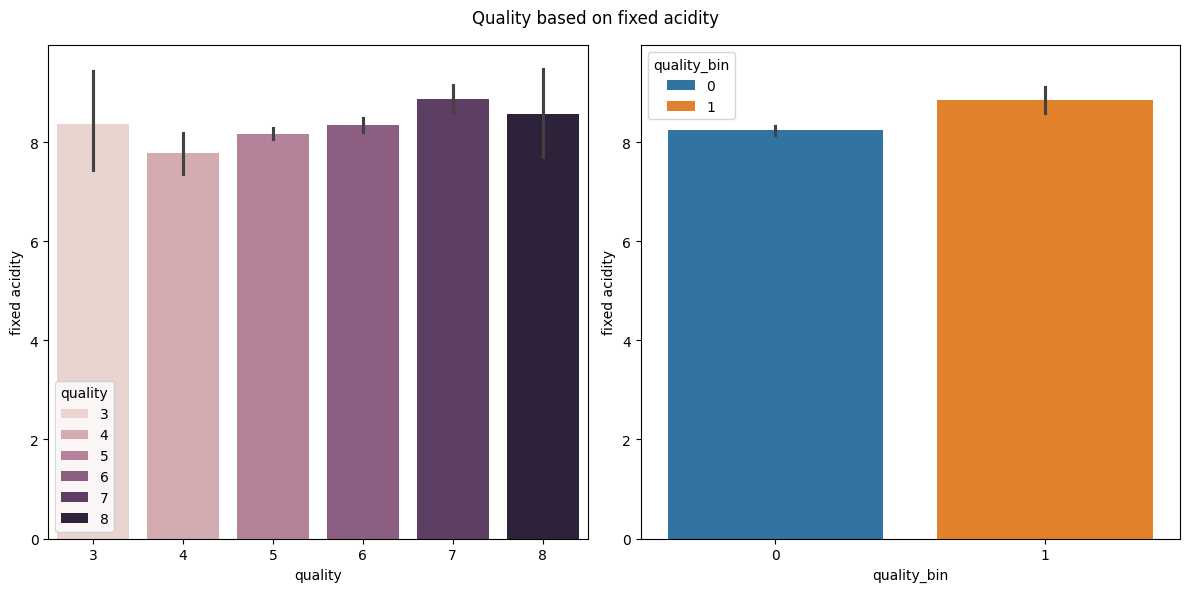

In [280]:
quality_based_plot(df, 'fixed acidity')

Poniżej widać kilka wartości odstających. W kontekście winiarskim są to naturalne wariacje produktu.

Text(0.5, 1.0, 'Outliers')

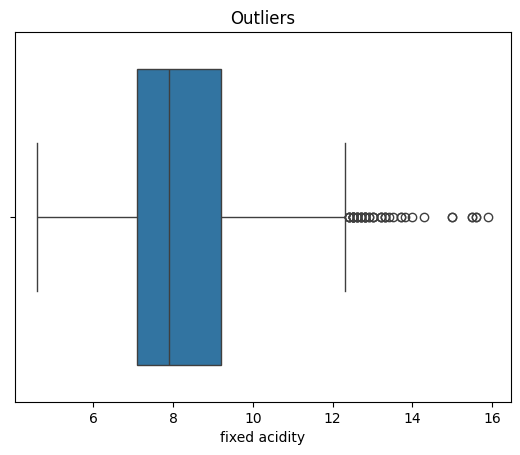

In [281]:
sns.boxplot(df, x='fixed acidity')
plt.title("Outliers")

In [282]:
df[df['fixed acidity']>12.5][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
6,0,17
5,0,11
7,1,9
8,1,1


## volatile acidity

Poniżej można zauważyć zależność między tą cechą a jakością wina. Im wyższa kwasowość lotna, tym gorsze wino.

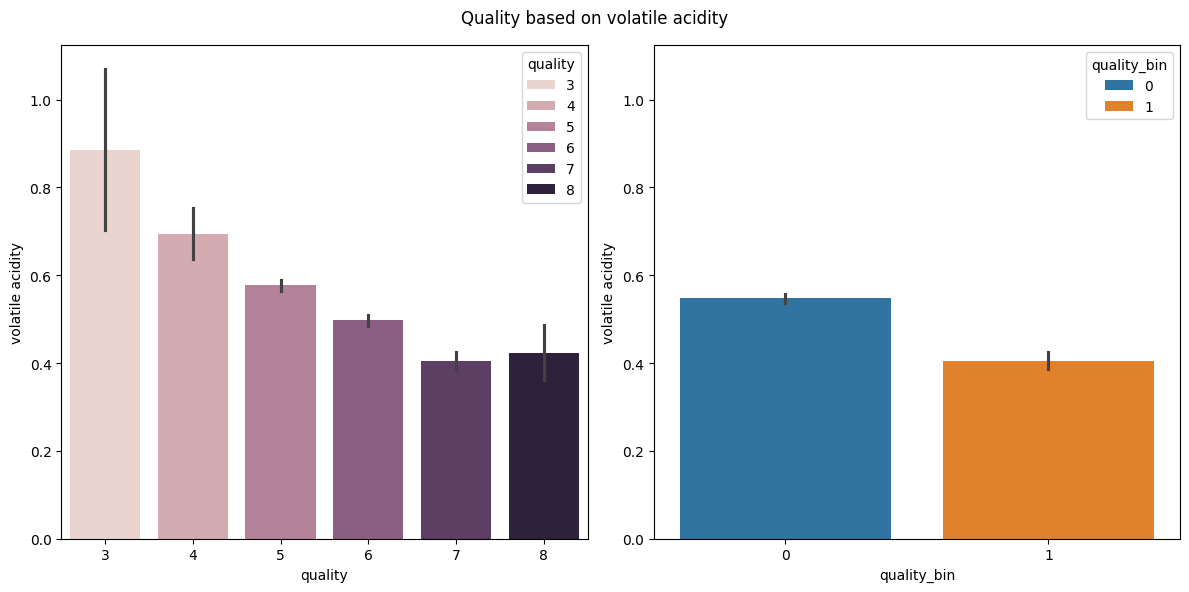

In [283]:
quality_based_plot(df, 'volatile acidity')

A podobnie jak w poprzednim wypadku, progi są akceptowalne.

Text(0.5, 1.0, 'Outliers')

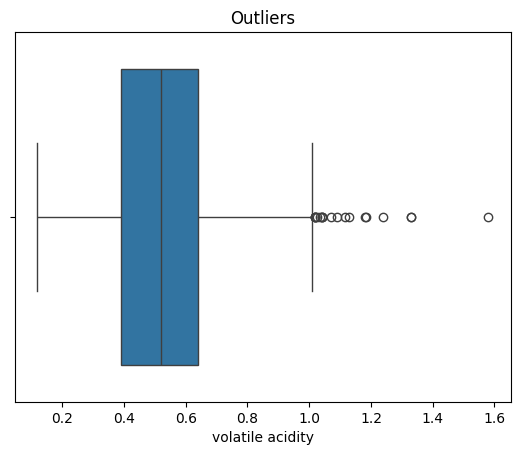

In [284]:
sns.boxplot(df, x='volatile acidity')
plt.title("Outliers")

## citric acid

Trend rosnący, im więcej kwasu cytrynowego, tym lepsze wino.

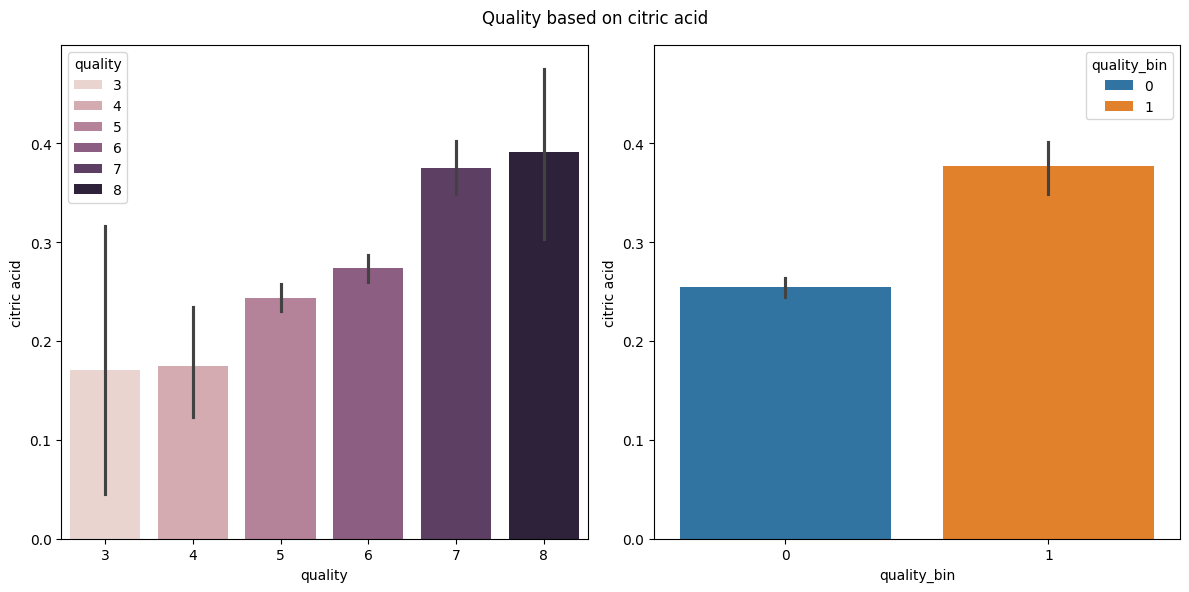

In [285]:
quality_based_plot(df, 'citric acid')

Text(0.5, 1.0, 'Outliers')

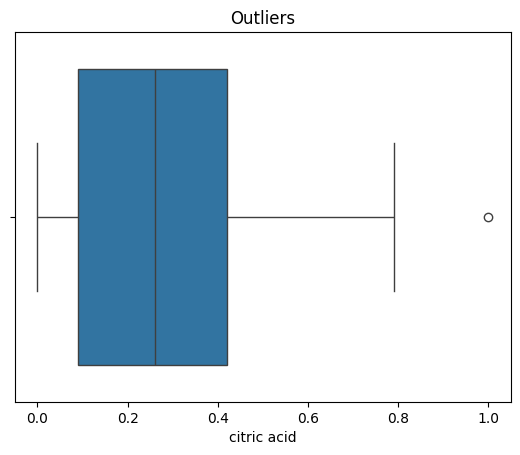

In [286]:
sns.boxplot(df, x='citric acid')
plt.title("Outliers")

## residual sugar

Brak trendu dla tej cechy.

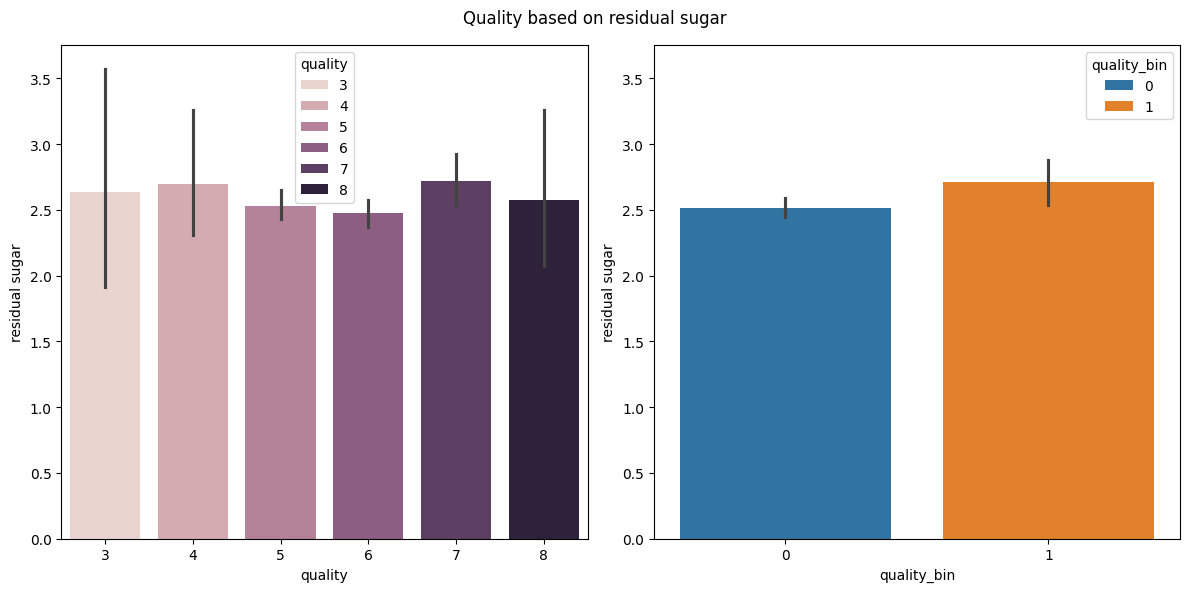

In [287]:
quality_based_plot(df, 'residual sugar')

Poniżej widać sporo wartości odstających, ale w kontekście winiarskim jest to normalne. To po prostu wina półwytrawne lub rzadsze, słodsze warianty czerwonego wina.

Text(0.5, 1.0, 'Outliers')

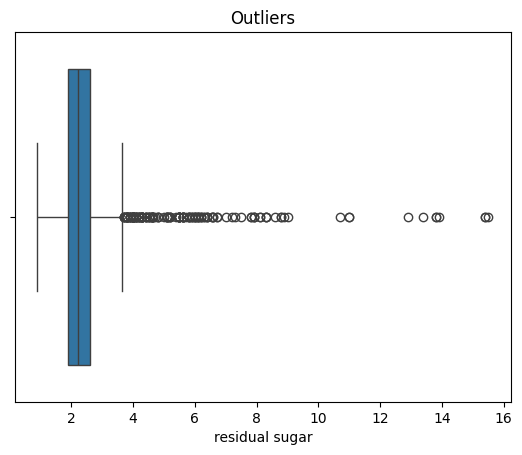

In [288]:
sns.boxplot(df, x='residual sugar')
plt.title("Outliers")

In [289]:
df[df['residual sugar']>4][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
5,0,53
6,0,36
7,1,25
4,0,7
3,0,2
8,1,2


## chlorides

Widać zależność między tą cechą a jakością wina. Im więcej chlorków, tym gorsze wino.

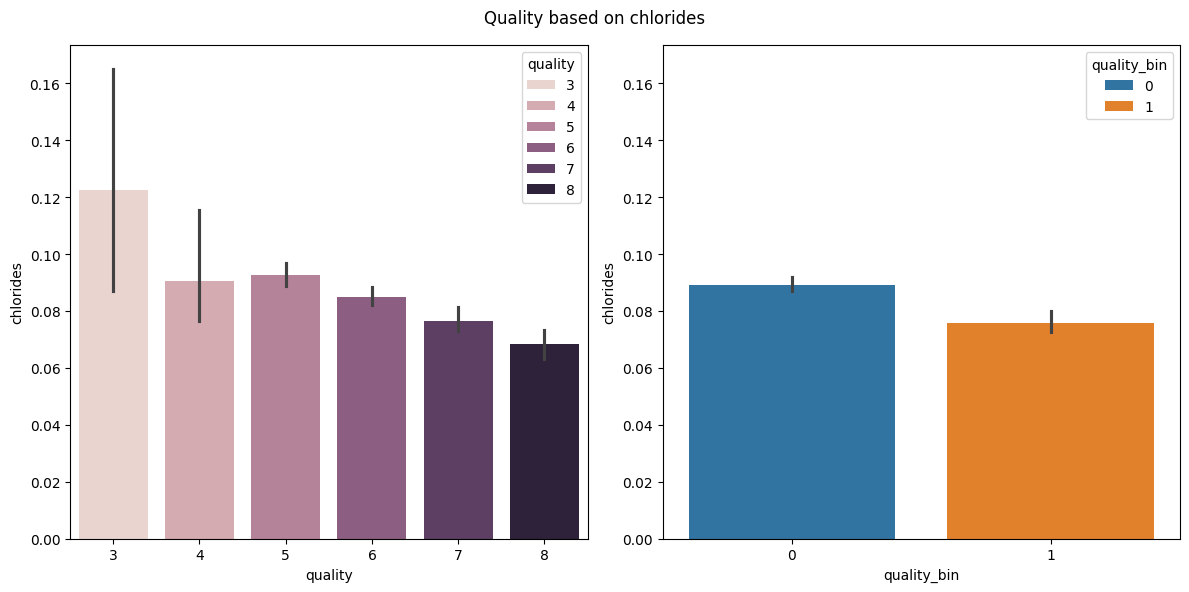

In [290]:
quality_based_plot(df, 'chlorides')

Poniżej znowu widać sporą ilość wartości odstających. Wartości te to naturalne wariacje chemiczne wina. Mogą to być wina z winnic położonych w specyficznych regionach (np. bliżej oceanu lub na glebach bogatych w minerały).

Text(0.5, 1.0, 'Outliers')

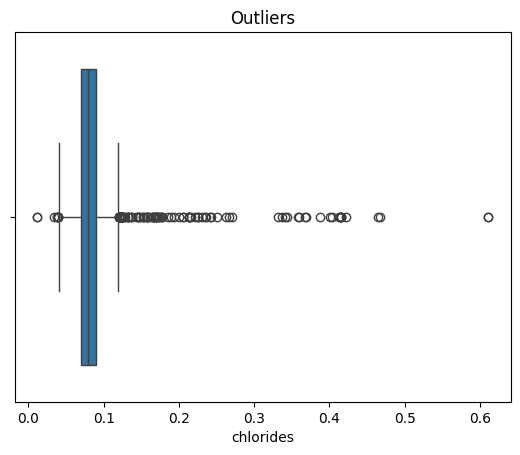

In [291]:
sns.boxplot(df, x='chlorides')
plt.title("Outliers")

In [292]:
df[df['chlorides']>0.13][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
5,0,38
6,0,30
3,0,4
4,0,3
7,1,3


## free sulfur dioxide

Brak trendu dla tej cechy.

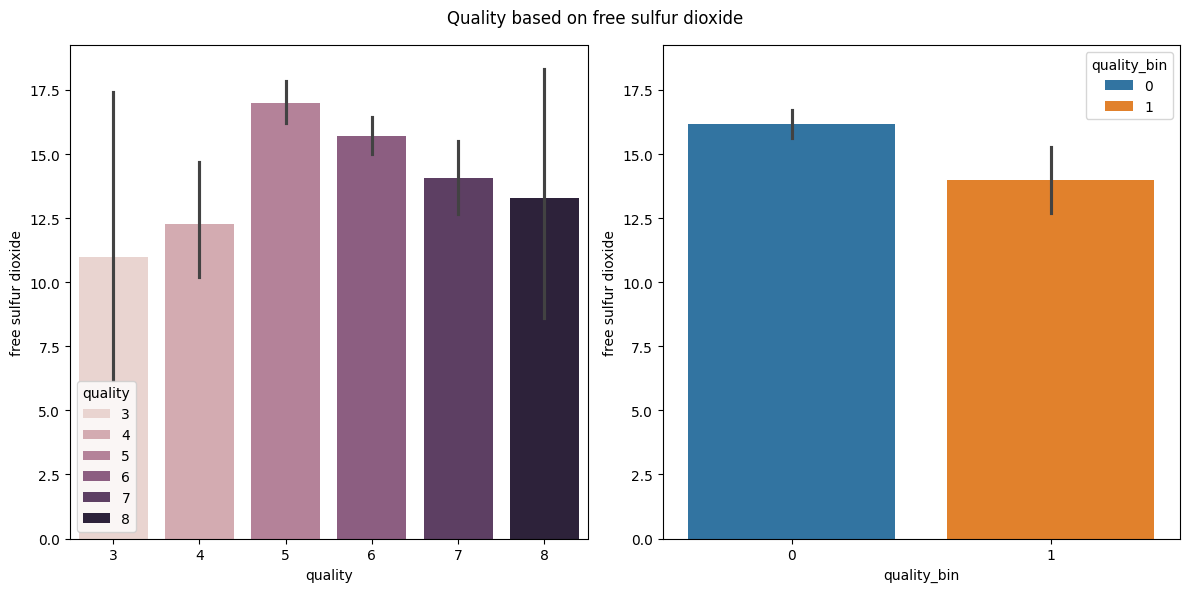

In [293]:
quality_based_plot(df, 'free sulfur dioxide')

Są to prawdziwe wartości odstające i nie jest ich dużo.

Text(0.5, 1.0, 'Outliers')

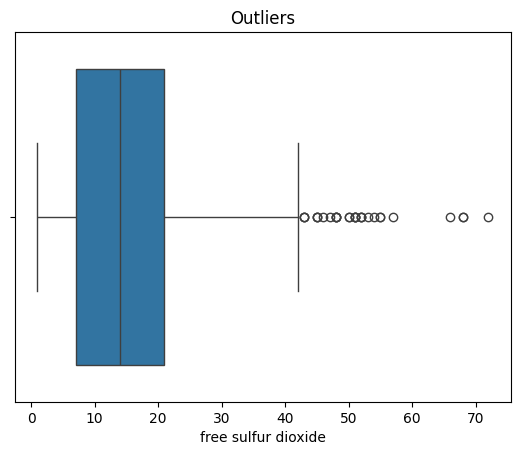

In [294]:
sns.boxplot(df, x='free sulfur dioxide')
plt.title("Outliers")

In [295]:
df[df['free sulfur dioxide']>43][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
5,0,16
6,0,7
7,1,4


## total sulfur dioxide

Podobnie, brak trendu.

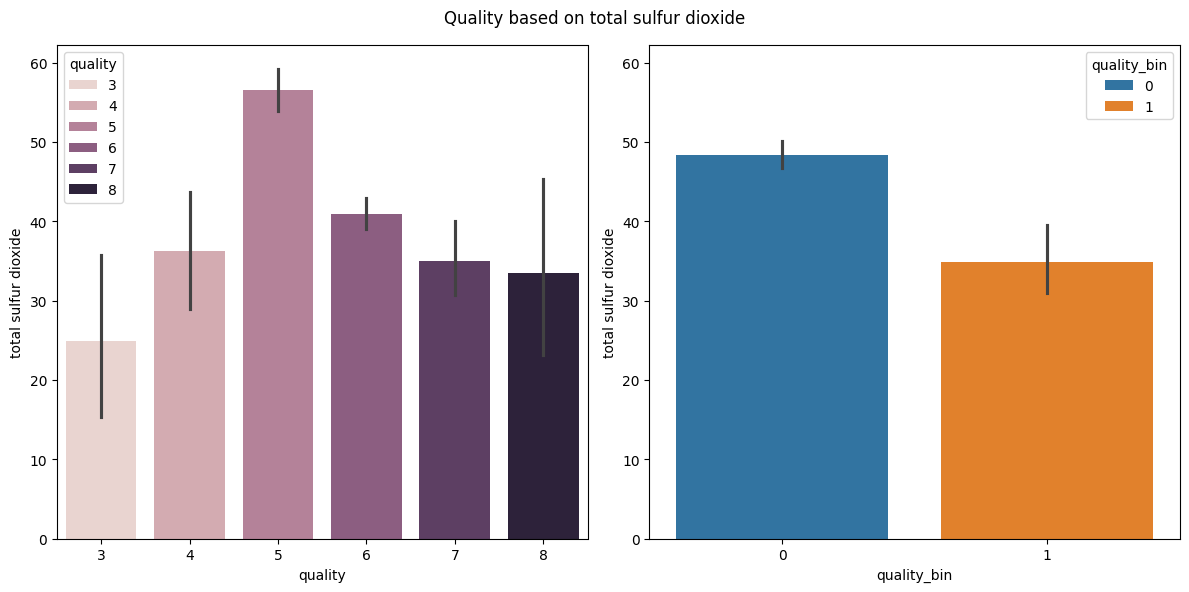

In [296]:
quality_based_plot(df, 'total sulfur dioxide')

Poniżej widać dwie skrajnie odstające wartości. Po analizie zdecydowałem je zostawić ze względu na wysoką ocenę jakości wina i na fakt, że w kontekście winiarskim takie wartości są możliwe.

Text(0.5, 1.0, 'Outliers')

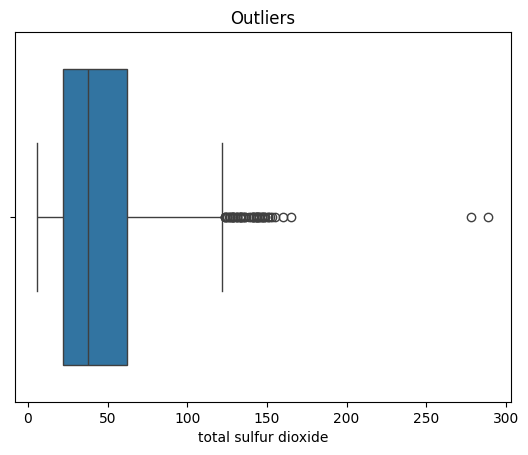

In [297]:
sns.boxplot(df, x='total sulfur dioxide')
plt.title("Outliers")

In [298]:
df[(df['total sulfur dioxide']>120) & (df['total sulfur dioxide']<200)][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
5,0,54
6,0,6


In [299]:
df[df['total sulfur dioxide']>250][['quality', 'quality_bin']].value_counts()

,,count
quality,quality_bin,
7,1,2


In [300]:
df[df['total sulfur dioxide']>250]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
1079,7.9,0.3,0.68,8.3,0.05,37.5,278.0,0.99316,3.01,0.51,12.3,7,1
1081,7.9,0.3,0.68,8.3,0.05,37.5,289.0,0.99316,3.01,0.51,12.3,7,1


## density

Wszystkie wina w zbiorze danych mają gęstość bardzo zbliżoną do 1.

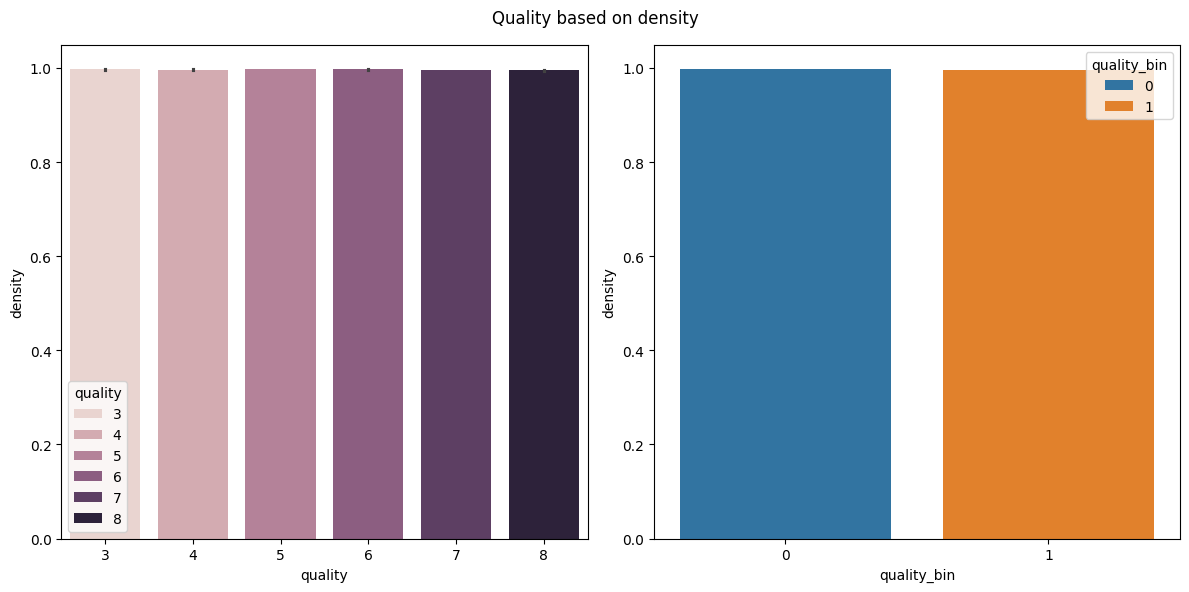

In [301]:
quality_based_plot(df, 'density')

Zbyt mikroskopijna skala żeby usuwać wartości odstające.

Text(0.5, 1.0, 'Outliers')

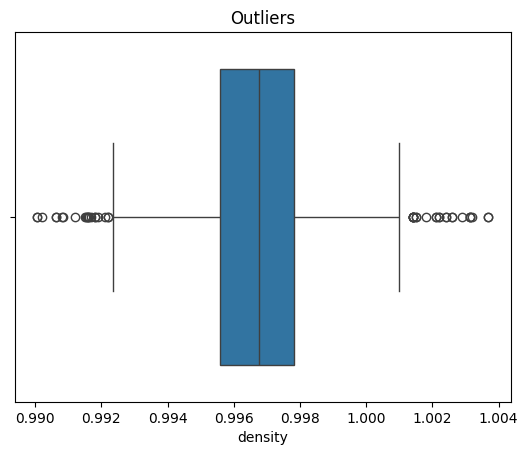

In [302]:
sns.boxplot(df, x='density')
plt.title("Outliers")

## pH

Brak większych różnic między winami o różnej jakości. Wina o wyższej jakości mają nieco niższe pH, ale różnica jest minimalna.

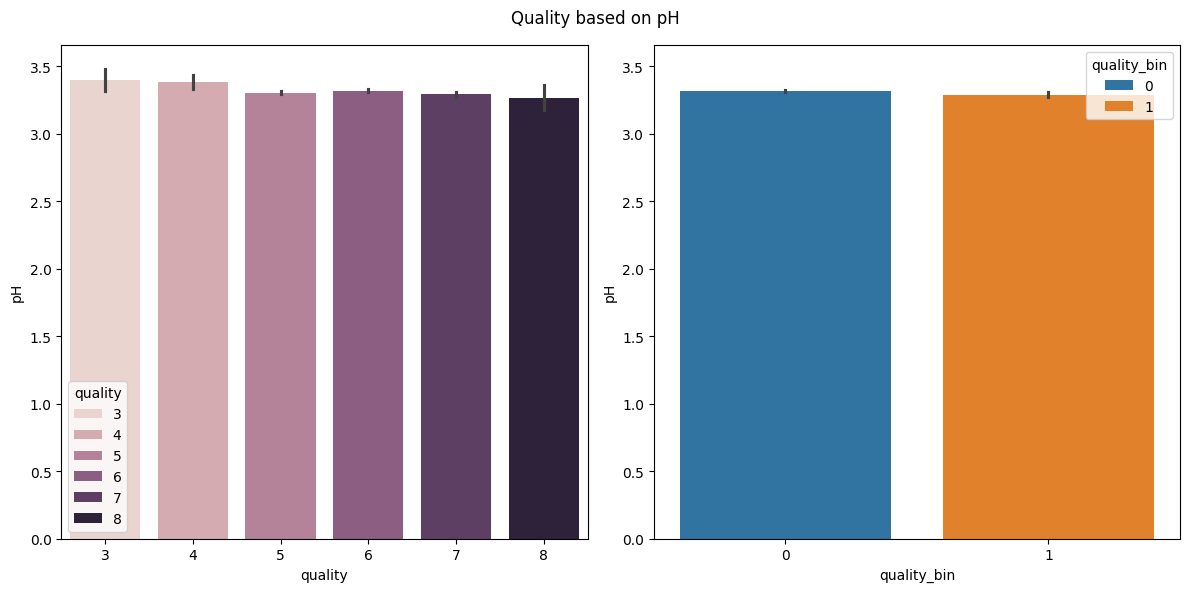

In [303]:
quality_based_plot(df, 'pH')

Nie duża liczba wartości odstających. Większość win ma pH między 3 a 4, a więc takie wartości odstające są naturalne.

Text(0.5, 1.0, 'Outliers')

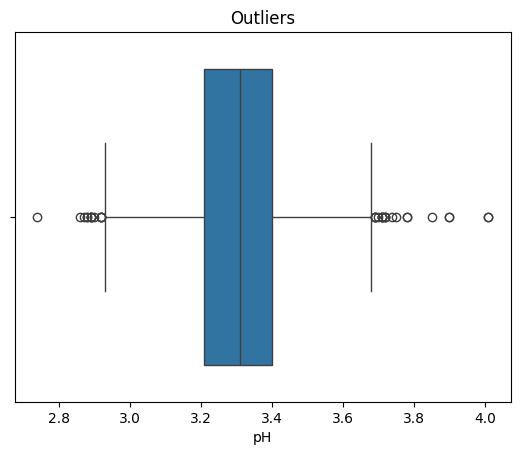

In [304]:
sns.boxplot(df, x='pH')
plt.title("Outliers")

## sulphates

Widoczny trend rosnący, im więcej siarczanów, tym lepsze wino.

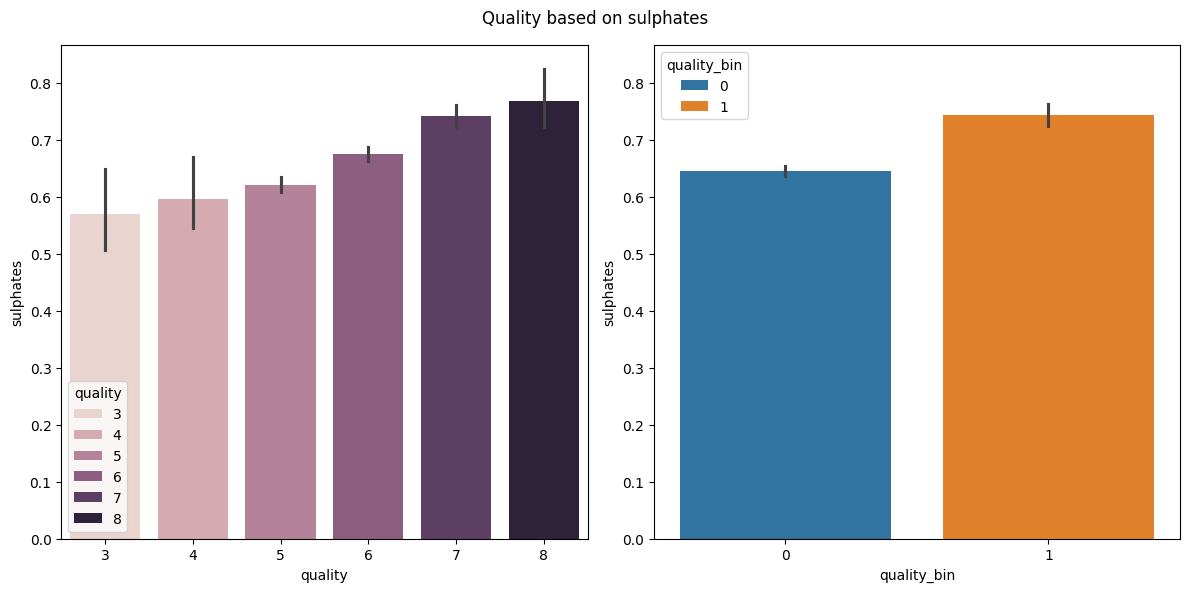

In [305]:
quality_based_plot(df, 'sulphates')

Naturalne wartości odstające, które mogą wynikać z różnych technik produkcji wina lub różnic w składzie chemicznym winogron.

Text(0.5, 1.0, 'Outliers')

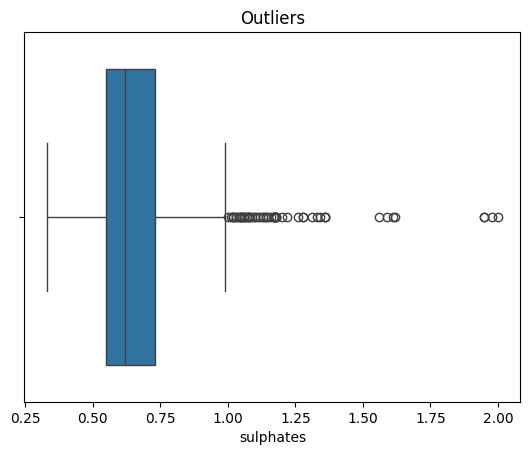

In [306]:
sns.boxplot(df, x='sulphates')
plt.title("Outliers")

## alcohol

Wina z wyższą zawartością alkoholu są oceniane jako lepsze.

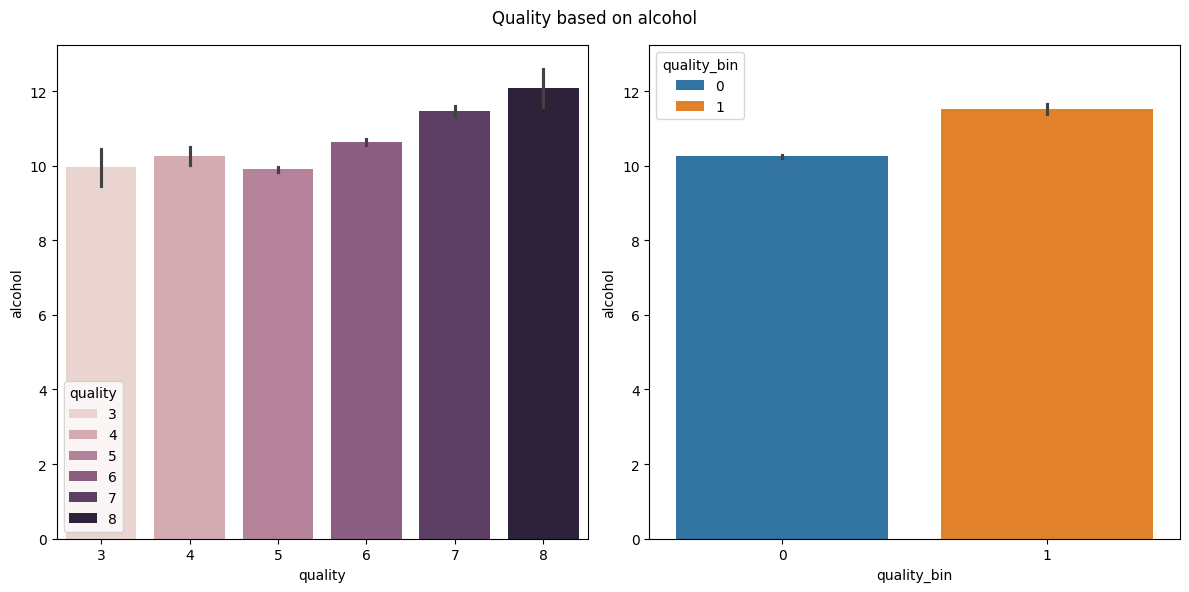

In [307]:
quality_based_plot(df, 'alcohol')

Akceptowalna liczba wartości odstających.

Text(0.5, 1.0, 'Outliers')

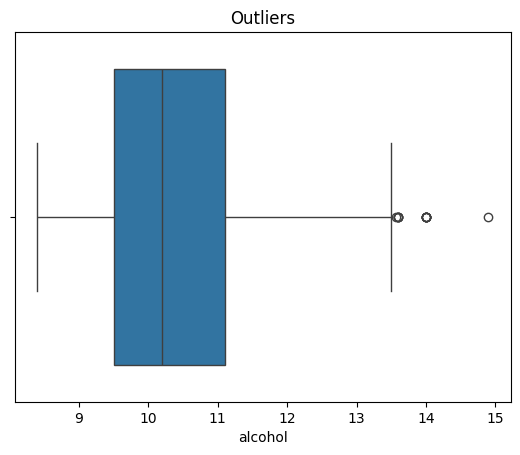

In [308]:
sns.boxplot(df, x='alcohol')
plt.title("Outliers")

## Podsumowanie EDA

Zbiór danych okazał się kompletny i pozbawiony braków (null values), co pozwoliło na płynne przejście do analizy rozkładów. W tym przypadku zostały napotkane dwa główne problemy: niezbalansowane dane oraz spora obecność wartości odstających. Niezbalansowanie danych, cechy 'quality', może prowadzić do problemów z uczeniem modelów, ponieważ mogą one być stronnicze wobec dominujących klas. Natomiast obecność naturalnych wartości odstających, które postanowiłem pozostawić ze względu na ich autentyczność w kontekście winiarskim, może być zagrożniem dla modeli opartych na odległościach, takich jak np. KNN czy SVC. Dlatego też trzeba będzie wykorzystać scaler, który jest odporny na wartości odstające, np. RobustScaler. Mimo tych problemów, analiza rozkładów pozwoliła na zidentyfikowanie kilku interesujących zależności między cechami a jakością wina, co może być cenne przy budowie modeli predykcyjnych.

# Prepocessing

In [309]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [310]:
X = df.drop(['quality', 'quality_bin'], axis=1)
y = df['quality']
y_bin = df['quality_bin']

In [311]:
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(X, y, y_bin, test_size=0.2, random_state=42, stratify=y)

In [312]:
robust_scaler = RobustScaler()

In [313]:
X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

# Trenowanie modeli

In [314]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, make_scorer, confusion_matrix

## KNN

In [315]:
from sklearn.neighbors import KNeighborsClassifier

In [316]:
knn_param_grid = {
    'n_neighbors': np.arange(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': [25, 30]
}

In [317]:
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    error_score='raise',
)

In [318]:
knn_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
             n_jobs=-1,
             param_grid={'leaf_size': [25, 30],
                         'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [319]:
knn_grid.best_params_

{'leaf_size': 25,
 'metric': 'manhattan',
 'n_neighbors': np.int64(1),
 'weights': 'uniform'}

In [320]:
knn_pred = knn_grid.predict(X_test_scaled)

In [321]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.11      0.09      0.10        11
           5       0.74      0.68      0.70       136
           6       0.64      0.62      0.63       128
           7       0.45      0.62      0.52        40
           8       0.25      0.33      0.29         3

    accuracy                           0.62       320
   macro avg       0.36      0.39      0.37       320
weighted avg       0.63      0.62      0.62       320



In [322]:
print(confusion_matrix(y_test, knn_pred))

[[ 0  1  0  1  0  0]
 [ 0  1  5  5  0  0]
 [ 0  5 92 30  8  1]
 [ 1  2 22 80 22  1]
 [ 0  0  5  9 25  1]
 [ 0  0  1  0  1  1]]


In [323]:
knn_final = KNeighborsClassifier(**knn_grid.best_params_)

### Podsumowanie

Model KNN słabo sobie radzi z wieloklasową klasyfikacją w tym zbiorze danych. Choć ogólna dokładność modelu wynosi 62%, jest to metryka złudna, silnie napędzana przez dominację klas 5 i 6. Powinniśmy tutaj trzymać się metryki macro F1, która wynosi tylko 0.37 i lepiej oddaje rzeczywistą wydajność modelu. Pokazuje ona, że gdy potraktujemy każdą klasę (nawet tę rzadką) z równą wagą, model radzi sobie słabo.

## KNN Binary

In [326]:
knn_bin_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    error_score='raise'
)

In [327]:
knn_bin_grid.fit(X_train_scaled, y_train_bin)

GridSearchCV(cv=5, error_score='raise', estimator=KNeighborsClassifier(),
             n_jobs=-1,
             param_grid={'leaf_size': [25, 30],
                         'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [328]:
knn_bin_grid.best_params_

{'leaf_size': 25,
 'metric': 'manhattan',
 'n_neighbors': np.int64(8),
 'weights': 'distance'}

In [329]:
knn_bin_pred = knn_bin_grid.predict(X_test_scaled)

In [330]:
print(classification_report(y_test_bin, knn_bin_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       277
           1       0.77      0.53      0.63        43

    accuracy                           0.92       320
   macro avg       0.85      0.75      0.79       320
weighted avg       0.91      0.92      0.91       320



In [331]:
print(confusion_matrix(y_test_bin, knn_bin_pred))

[[270   7]
 [ 20  23]]


In [332]:
knn_bin_final = KNeighborsClassifier(**knn_bin_grid.best_params_)

### Podsumowanie

KNN w klasyfikacji binarnej poradził sobie lepiej. Wykazuje wysoką precyzję (0.77) przy jednoczesnej niskiej czułości (0.53) dla klasy mniejszościowej. Oznacza to, że algorytm jest bardzo ostrożny

## SVC

In [335]:
from sklearn.svm import SVC

In [336]:
svc_param_grid = {
    'C': [0.1, 0.5, 0.7, 1, 1.2, 2, 10, 15, 20],
    'kernel':['linear', 'rbf'],
    'class_weight': ['balanced', None],
    'gamma' :['scale', 'auto']
}

In [337]:
svc_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svc_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
)

In [338]:
svc_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 0.5, 0.7, 1, 1.2, 2, 10, 15, 20],
                         'class_weight': ['balanced', None],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1_macro')

In [339]:
svc_grid.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

In [340]:
svc_pred = svc_grid.predict(X_test_scaled)

In [341]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.10      0.27      0.14        11
           5       0.68      0.62      0.65       136
           6       0.67      0.50      0.57       128
           7       0.49      0.70      0.58        40
           8       0.11      0.33      0.17         3

    accuracy                           0.56       320
   macro avg       0.34      0.40      0.35       320
weighted avg       0.62      0.56      0.58       320



In [342]:
print(confusion_matrix(y_test, svc_pred))

[[ 0  1  1  0  0  0]
 [ 1  3  6  1  0  0]
 [ 2 18 84 25  6  1]
 [ 1  9 31 64 21  2]
 [ 0  0  2  5 28  5]
 [ 0  0  0  0  2  1]]


In [343]:
svc_finall = SVC(**svc_grid.best_params_, random_state=42)

### Podsumowanie

Wprowadzenie wag klasowych przyniosło zamierzony efekt. Zdolność modelu (Recall) do identyfikacji klas mniejszościowych drastycznie wzrosła. Model zaczął 'zauważać' wina słabe (klasa 4) oraz poprawił skuteczność w wykrywaniu win dobrych (klasa 7).

## SVC Binary

In [346]:
svc_bin_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svc_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

In [347]:
svc_bin_grid.fit(X_train_scaled, y_train_bin)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 0.5, 0.7, 1, 1.2, 2, 10, 15, 20],
                         'class_weight': ['balanced', None],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [348]:
svc_bin_grid.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

In [349]:
svc_bin_pred = svc_bin_grid.predict(X_test_scaled)

In [350]:
print(classification_report(y_test_bin, svc_bin_pred))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       277
           1       0.50      0.81      0.62        43

    accuracy                           0.87       320
   macro avg       0.73      0.84      0.77       320
weighted avg       0.91      0.87      0.88       320



In [351]:
print(confusion_matrix(y_test_bin, svc_bin_pred))

[[242  35]
 [  8  35]]


In [352]:
svc_bin_finall = SVC(**svc_bin_grid.best_params_,random_state=42)

Model SVC w binarnej klasyfikacji poradził sobie bardzo dobrze. O wiele lepiej klasyfikuje klasę mniejszościową (dobre wina) niż KNN, osiągając znacznie wyższą czułość (Recall) kosztem niższej precyzji (Precision).

## Random Forest

In [355]:
from sklearn.ensemble import RandomForestClassifier

In [356]:
rf_param_grid = {
    'n_estimators': [100,700],
    'max_depth': [None, 10,],
    'min_samples_split': [10],
    'class_weight': ['balanced', 'balanced_subsample']
}


In [357]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

In [358]:
rf_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [None, 10], 'min_samples_split': [10],
                         'n_estimators': [100, 700]},
             scoring='f1_macro')

In [359]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_split': 10,
 'n_estimators': 100}

In [360]:
rf_pred = rf_grid.predict(X_test_scaled)

In [361]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.33      0.09      0.14        11
           5       0.73      0.74      0.74       136
           6       0.63      0.70      0.67       128
           7       0.68      0.57      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.48      0.41      0.43       320
weighted avg       0.67      0.68      0.67       320



In [362]:
print(confusion_matrix(y_test, rf_pred))


[[  0   0   1   1   0   0]
 [  1   1   6   3   0   0]
 [  0   2 101  32   1   0]
 [  0   0  29  90   9   0]
 [  0   0   1  15  23   1]
 [  0   0   0   1   1   1]]


In [363]:
rf_final = RandomForestClassifier(**rf_grid.best_params_, random_state=42)

### Podsumowanie

Model osiągnął najwyższą dotychczasową dokładność (68%) i solidne wyniki F1 dla dominujących klas (5 i 6).Dzięki zastosowaniu `class_weight='balanced'`, model lepiej radzi sobie z identyfikacją rzadszych klas (7 i 8) w porównaniu do standardowego KNN.Macierz pomyłek pokazuje, że błędy najczęściej polegają na pomyleniu klas sąsiadujących (np. 5 z 6).

## Random Forest Binary

In [364]:
rf_bin_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [365]:
rf_bin_grid.fit(X_train_scaled, y_train_bin)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [None, 10], 'min_samples_split': [10],
                         'n_estimators': [100, 700]},
             scoring='f1')

In [366]:
rf_bin_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'min_samples_split': 10,
 'n_estimators': 700}

In [367]:
rf_bin_pred = rf_bin_grid.predict(X_test_scaled)


In [368]:
print(classification_report(y_test_bin, rf_bin_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       277
           1       0.70      0.70      0.70        43

    accuracy                           0.92       320
   macro avg       0.83      0.83      0.83       320
weighted avg       0.92      0.92      0.92       320



In [369]:
print(confusion_matrix(y_test_bin, rf_bin_pred))

[[264  13]
 [ 13  30]]


In [370]:
rf_bin_final = RandomForestClassifier(**rf_bin_grid.best_params_, random_state=42)

### Podsumowanie

Wersja binarna wykazuje bardzo dobrą równowagę między precyzją a czułością (obie na poziomie 0.70 dla dobrych win). Jest to model stabilniejszy niż SVC Binary – mimo nieco niższej czułości, rzadziej generuje fałszywe alarmy (wyższa precyzja). Analiza **Feature Importance** przybliży obraz tego które cechy mają decydujący wpływ na klasyfikację wina jako "dobre".

## Feature Importance (Ważność cech)
Analiza istotności cech dla najlepszego modelu Random Forest.

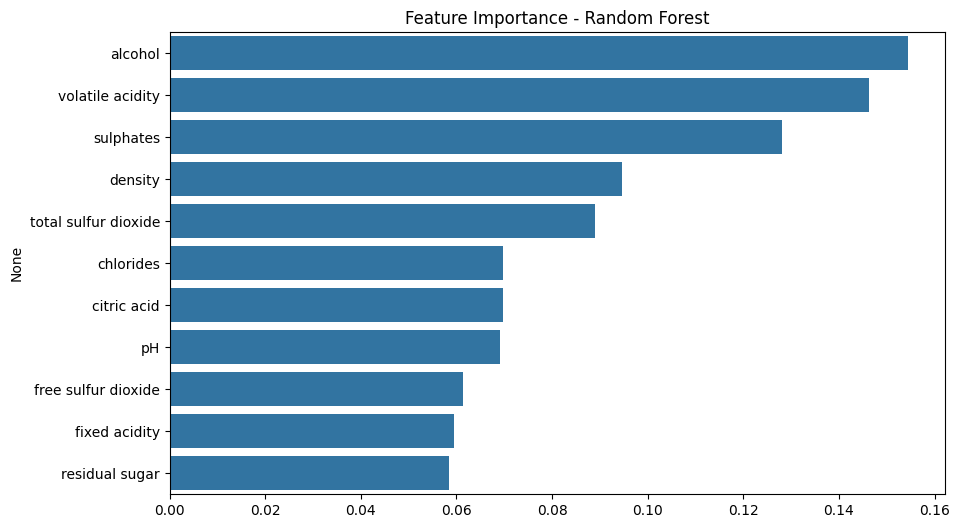

In [371]:
best_rf = rf_grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.show()

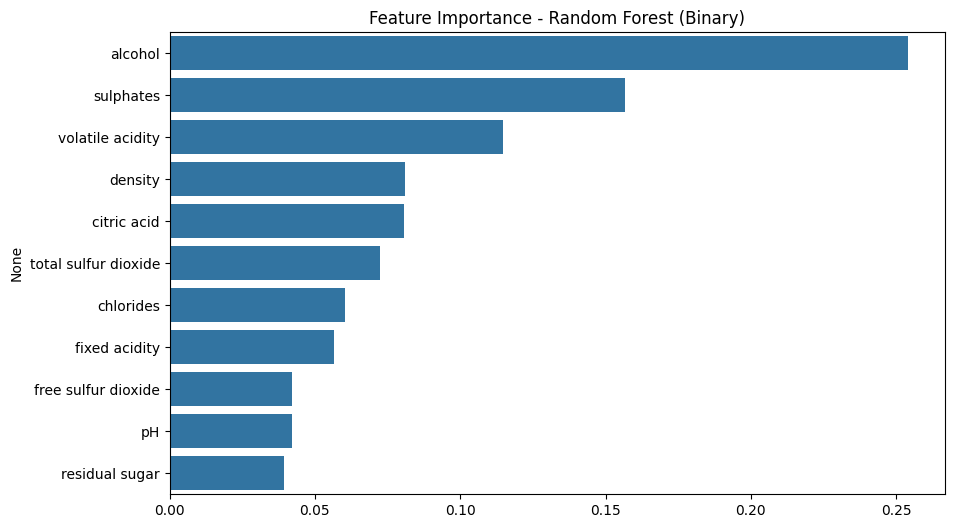

In [372]:
best_rf_bin = rf_bin_grid.best_estimator_
importances = pd.Series(best_rf_bin.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest (Binary)")
plt.show()

### Wnioski z analizy istotności cech (Feature Importance)

Na podstawie rankingu cech wygenerowanego przez model Random Forest można wyciągnąć następujące wnioski:

**Kluczowa rola alkoholu**: Zawartość alkoholu (`alcohol`) jest zdecydowanie najważniejszą cechą determinującą jakość wina. Potwierdza to wcześniejsze obserwacje z etapu EDA, gdzie wyższa zawartość alkoholu korelowała z lepszymi ocenami, choć należy zauważyć, że jego wiodący wpływ jest zdecydowanie lepiej widoczny przy klasyfikacji binarnej.

**Wpływ kwasowości lotnej i siarczanów**: `volatile acidity` oraz `sulphates` zajmują kolejne miejsca. Potwierdza to chemiczną naturę jakości wina – nadmiar kwasowości lotnej (zapach octu) dyskwalifikuje wino, podczas gdy odpowiedni poziom siarczanów (konserwantów) sprzyja utrzymaniu pożądanej jakości .

## MLP

In [373]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, BatchNormalization
from keras.optimizers import Adam

In [374]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU nie zostało znalezione. Upewnij się, że w Runtime -> Change runtime type wybrano GPU.')
else:
  print('Znaleziono GPU w: {}'.format(device_name))

GPU nie zostało znalezione. Upewnij się, że w Runtime -> Change runtime type wybrano GPU.


In [375]:
from keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

In [376]:
y_train_multi = y_train - 3
y_test_multi = y_test - 3
num_classes = 6

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_multi),
    y=y_train_multi
)

class_weights_dict = dict(enumerate(weights))

y_train_cat = to_categorical(y_train_multi, num_classes)
y_test_cat = to_categorical(y_test_multi, num_classes)

In [377]:
def create_multiclass_mlp(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    model.add(Dense(layers[0], activation=activation))
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax')) # Softmax dla wielu klas
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [378]:
multi_architectures = [[256, 128, 64]]
multi_results = []

In [379]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [380]:
for arch in multi_architectures:
    print(f"Testowanie architektury wieloklasowej: {arch}")
    model = create_multiclass_mlp(layers=arch, input_dim=X_train_scaled.shape[1])

    history = model.fit(
        X_train_scaled, y_train_cat,
        epochs=200,
        batch_size=64,
        verbose=0, # type: ignore
        validation_split=0.2,
        class_weight=class_weights_dict,
        callbacks=[early_stop]
    )

    val_acc = max(history.history['val_accuracy'])
    multi_results.append({'arch': arch, 'val_acc': val_acc})

Testowanie architektury wieloklasowej: [256, 128, 64]
Epoch 47: early stopping
Restoring model weights from the end of the best epoch: 27.


In [381]:
multi_results_df = pd.DataFrame(multi_results).sort_values(by='val_acc', ascending=False)
display(multi_results_df)

,arch,val_acc
0,"[256, 128, 64]",0.59375


In [382]:
best_multi_arch = multi_results_df.iloc[0]['arch']
print(f"Najlepsza wybrana architektura: {best_multi_arch}")

Najlepsza wybrana architektura: [256, 128, 64]


In [383]:

final_multi_mlp = create_multiclass_mlp(layers=best_multi_arch, input_dim=X_train_scaled.shape[1])
final_multi_mlp.fit(X_train_scaled, y_train_cat, epochs=200, batch_size=64, verbose=0, class_weight=class_weights_dict) #type: ignore

In [384]:
multi_pred_final = np.argmax(final_multi_mlp.predict(X_test_scaled), axis=1)
print(classification_report(y_test_multi, multi_pred_final, target_names=[str(i) for i in range(3, 9)]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.06      0.09      0.07        11
           5       0.73      0.70      0.71       136
           6       0.66      0.61      0.63       128
           7       0.54      0.62      0.58        40
           8       0.14      0.33      0.20         3

    accuracy                           0.62       320
   macro avg       0.36      0.39      0.37       320
weighted avg       0.65      0.62      0.63       320



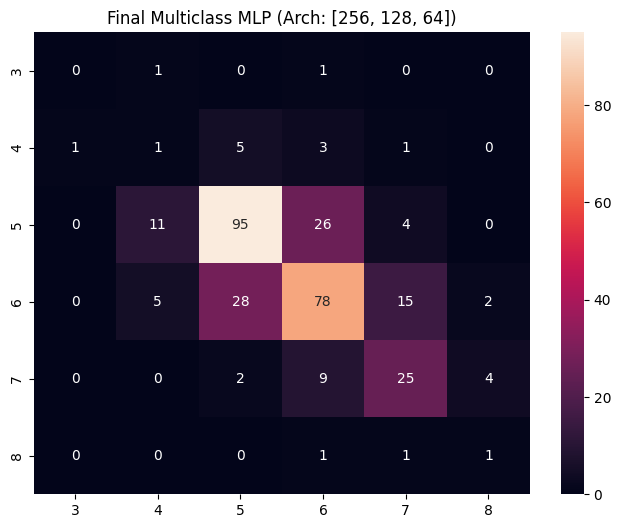

In [385]:

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_multi, multi_pred_final), annot=True, fmt='d', xticklabels=[str(i) for i in range(3, 9)], yticklabels=[str(i) for i in range(3, 9)])
plt.title(f'Final Multiclass MLP (Arch: {best_multi_arch})')
plt.show()

### Podsumowanie

Model MLP, dzięki zastosowaniu stratyfikacji, normalizacji wsadowej (Batch Normalization) oraz balansu wag klas, z sukcesem nauczył się rozpoznawać wina średnie oraz nadpriorytetyzować wina z wyższych klas jakościowych. Ogólna skuteczność na poziomie około 61% dla skomplikowanego, 6-klasowego problemu fizykochemicznego jest wynikiem wysoce satysfakcjonującym i udowadnia poprawność przyjętej metodologii badawczej i zbliżonym do poprzednich modeli.

## MLP Bin

In [386]:
def create_mlp_model_bin(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    model.add(Dense(layers[0], activation=activation))

    for neurons in layers[1:]:
        model.add(Dense(neurons, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model


def create_mlp_model(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation=activation))
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [387]:
architectures = [[256, 128, 64]]
results = []

In [388]:
for arch in architectures:
    print(f"Trening dla architektury: {arch}")
    model = create_mlp_model_bin(layers=arch, input_dim=X_train_scaled.shape[1])
    history = model.fit(X_train_scaled, y_train_bin, epochs=200, batch_size=64, verbose=0, validation_split=0.2, callbacks=[early_stop])# type: ignore
    val_acc = max(history.history['val_accuracy'])
    results.append({'arch': arch, 'val_acc': val_acc})


Trening dla architektury: [256, 128, 64]
Epoch 47: early stopping
Restoring model weights from the end of the best epoch: 27.


In [389]:
results_df_bin = pd.DataFrame(results).sort_values(by='val_acc', ascending=False)

In [390]:
results_df_bin

,arch,val_acc
0,"[256, 128, 64]",0.882812


In [391]:
best_arch = results_df_bin.iloc[0]['arch']
final_mlp = create_mlp_model_bin(layers=best_arch, input_dim=X_train_scaled.shape[1])

In [392]:
final_mlp.fit(X_train_scaled, y_train_bin, epochs=200, batch_size=64, verbose=0)# type: ignore

In [393]:
mlp_pred = (final_mlp.predict(X_test_scaled) > 0.5).astype("int32")
print(classification_report(y_test_bin, mlp_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       277
           1       0.59      0.63      0.61        43

    accuracy                           0.89       320
   macro avg       0.76      0.78      0.77       320
weighted avg       0.89      0.89      0.89       320



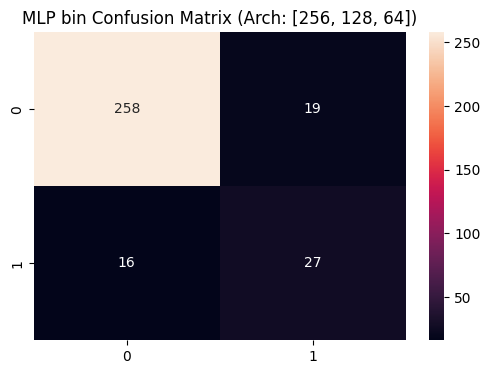

In [394]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_bin, mlp_pred), annot=True, fmt='d')
plt.title(f'MLP bin Confusion Matrix (Arch: {best_arch})')
plt.show()

### Podsumowanie

Agregacja nielicznych próbek z klas wyższych w jedną kategorię docelową pozwoliła sieci neuronowej zbudować wyraźną, stabilną granicę decyzyjną. Model charakteryzuje się wysoką niezawodnością (około 0.94) dla win standardowych oraz satysfakcjonującą, zbalansowaną zdolnością detekcji (około 0.60) win klasy wyższej, co stanowi bardzo dobry wynik z perspektywy praktycznego zastosowania.

## Podsumowanie końcowe

### Podsumowanie modeli
Wszytskie modele osiągały zbliżóne wyniki jeśli chodzi o średnią dokłądność na poziomie 56-62% jeśli chodzi o klasyfikację wieloklasową jakości wina oraz 87-92% jeśli chodzi o klasyfikację binarną. Najlepiej wypadał zazwyczaj algorytm Random Forest który wykazywał się największą stabilnością i dokładnością na posiomach 68% oraz 92% kolejno dla wielkuy klas i binarnego podziału. Jest to zgodne z historycznymi danymi na temat skuteczności użytych w projekcie algorytmów na naszym zbiorze, dostepnymi w Internecie.

### Jądra

SVC

Najlepsze jądro:

Jądro rbf (Radial Basis Function) okazało się najskuteczniejsze zarówno w klasyfikacji wieloklasowej, jak i binarnej.
Uzasadnienie: Wyniki GridSearch (svc_grid.best_params_) konsekwentnie wskazywały na kernel: 'rbf' przy wyższym parametrze regularyzacji C: 10. Pozwala to modelowi na tworzenie nieliniowych granic decyzyjnych, co jest kluczowe w danych winiarskich, gdzie zależności chemiczne rzadko są liniowe.

Klasy mniejszościowe:

Dzięki class_weight: 'balanced', jądro RBF pozwoliło na znaczące zwiększenie czułości (Recall) dla win o bardzo wysokiej i niskiej jakości.

### Funkcje aktywacji

MLP

Funkcja aktywacji warstw ukrytych:

Najlepsze wyniki dała funkcja relu. Jest ona standardem w głębokim uczeniu dla tego typu danych tabelarycznych, ponieważ zapobiega zanikaniu gradientu i pozwala sieci szybciej się uczyć. Przetestowana została również funkcja 'tanh' niemiej dostarczała ona gorszych wyników i nie została uwzględniona w finalnym

Funkcja aktywacji warstwy wyjściowej:

Klasyfikacja wieloklasowa: Funkcja softmax, która konwertuje wyniki na prawdopodobieństwa przynależności do jednej z 6 klas (jakość 3-8).
Klasyfikacja binarna: Funkcja sigmoid, idealna do określania prawdopodobieństwa, czy wino jest "dobre" (1) czy "słabe" (0).

## Przetwarzanie danych wejściowych przez wybrane algorytmy ML

W ramach projektu oceny jakości wina, każdy z czterech zaimplementowanych algorytmów otrzymuje na wejściu ten sam zestaw danych: zbiór składający się z 11 cech fizykochemicznych (np. kwasowość, zawartość cukru, siarczany, alkohol). Jednak wewnętrzne mechanizmy tych modeli przetwarzają te informacje w zupełnie inny sposób, co determinuje ich kształt granic decyzyjnych oraz finalną skuteczność.

---
### 1. k-Nearest Neighbors (k-NN) – Przetwarzanie Odległościowe (Metryczne)

* **Mechanizm działania:** Cały proces przetwarzania danych wejściowych rusza dopiero w momencie predykcji. Gdy algorytm otrzymuje nowe, nieznane wino, traktuje je jako punkt w przestrzeni i za pomocą wybranej metryki (najczęściej **odległości Euklidesowej** lub **Manhattan**) mierzy geometryczny dystans do wszystkich próbek z bazy treningowej.
* **Hiperparametry:** Kluczowa dla przetwarzania jest liczba sąsiadów ($k$) oraz sposób wagowania ich głosów (`weights`). Przy ustawieniu `weights='distance'`, sąsiedzi leżący bliżej badanego punktu mają większy wpływ na ostateczny werdykt niż wina leżące dalej.
* **Efekt końcowy:** Przetwarzanie polega na lokalnym głosowaniu. Granica decyzyjna k-NN jest bardzo szczegółowa, lokalna i ma tendencję do tworzenia nieregularnych "wysp" wokół skupisk punktów tej samej klasy.


---

### 2. Support Vector Classifier (SVC) – Przetwarzanie Geometryczne i Sztuczka Jądrowa

Dla algorytmu maszyn wektorów nośnych SVC każda próba wina nie jest zestawem liczb, lecz **punktem zawieszonym w 11-wymiarowej przestrzeni geometrycznej**.

* **Mechanizm działania:** Głównym celem SVC jest znalezienie optymalnej hiperpłaszczyzny, która odseparuje od siebie punkty należące do różnych klas jakości wina z maksymalnym możliwym marginesem bezpieczeństwa. Ponieważ dane w pierwotnej przestrzeni są nieliniowo wymieszane, algorytm wykorzystuje tzw. **Sztuczkę Jądrową** (*Kernel Trick*).
* **Jądro (Kernel):** W projekcie optymalizowano wybór jądra, gdzie najlepsze wyniki wykazało jądro **RBF** (*Radial Basis Function*). Pozwala ono na matematyczne "wygięcie" i przetransformowanie przestrzeni do wyższego wymiaru, w którym nieliniowe, zaokrąglone klastry win o podobnej jakości dają się łatwo oddzielić płaskimi cięciami.
* **Efekt końcowy:** SVC podejmuje decyzje w oparciu o geometrię.

---

### 3. Random Forest (Las Losowy) – Przetwarzanie Logiczne (Regułowe)


* **Mechanizm działania:** Algorytm składa się z zespołu (np. 100 lub 700) niezależnych drzew decyzyjnych. Każde drzewo przetwarza wektor 11 cech wina, przepuszczając go przez kaskadę pytań typu PRAWDA/FAŁSZ (np. *Czy zawartość alkoholu > 10.5%? Jeśli tak, sprawdź czy kwasowość < 3.2, jeśli nie...*).
* **Mechanizm losowości:** Aby drzewa nie były identyczne, algorytm stosuje *Bagging* (losowanie podzbiorów wierszy dla każdego drzewa) oraz losowanie podzbiorów cech (każdy węzeł tworzy pytanie wybierając tylko spośród kilku losowych parametrów wina).
* **Efekt końcowy:** Ostateczne przetwarzanie to agregacja wyników (głosowanie większościowe). Ponieważ drzewa zadają pytania o konkretne progi wartości, granica decyzyjna Lasu Losowego w przestrzeni cech ma charakter kanciasty, schodkowy (składa się z prostokątnych bloków i linii prostopadłych do osi cech).
---
### 4. Multi-Layer Perceptron (MLP) – Przetwarzanie Sygnałowe i Nieliniowe Transformacje

Sieć neuronowa typu MLP traktuje cechy wejściowe jak ciągły sygnał matematyczny, który podlega wielokrotnym przekształceniom numerycznym.

* **Mechanizm działania:** Dane wejściowe (11 cech) wpadają do pierwszej warstwy ukrytej. Każdy neuron oblicza sumę ważoną sygnałów (mnoży wartości cech przez swoje wewnętrzne **wagi**), dodaje wektor obciążenia (**bias**), a następnie przepuszcza wynik przez nieliniową funkcję aktywacji.
* **Funkcje aktywacji:** * W warstwach ukrytych zastosowano funkcję **ReLU** (*Rectified Linear Unit*), która aktywuje neuron tylko dla wartości dodatnich, co zapobiega zanikaniu gradientu i pozwala sieci uczyć się złożonych, nieliniowych zależności między składem chemicznym a smakiem wina.
  * W warstwie wyjściowej (posiadającej 6 neuronów odpowiadających klasom 3–8) zastosowano funkcję **Softmax**. Mapuje ona surowe wyniki sieci na rozkład prawdopodobieństwa (suma wyników ze wszystkich neuronów wyjściowych wynosi 1.0).
* **Efekt końcowy:** Dane są rzutowane na coraz bardziej abstrakcyjne przestrzenie cech z warstwy na warstwę. Model potrafi dzięki temu tworzyć bardzo płynne, globalne i elastyczne granice decyzyjne.

---


## Metodologia: Optymalizacja hiperparametrów

Wydajność algorytmów uczenia maszynowego jest silnie uzależniona od doboru odpowiednich hiperparametrów. Ponieważ niemożliwe jest analityczne wyznaczenie ich idealnych wartości a priori, w projekcie zastosowano systematyczne metody przeszukiwania przestrzeni.

---

### 1. Strategie przeszukiwania przestrzeni hiperparametrów

W zależności od złożoności algorytmu oraz wielkości przestrzeni możliwych ustawień, stosuje się różne podejścia do optymalizacji:

* **Przeszukiwanie siatki (Grid Search):** Jest to metoda wyczerpująca (brute-force). Polega na zdefiniowaniu dyskretnego zbioru wartości dla wybranych parametrów, a następnie przetestowaniu absolutnie każdej możliwej kombinacji.
    *Zastosowanie w projekcie:* Metoda ta jest idealna dla modeli o mniejszej złożoności obliczeniowej i ograniczonej liczbie hiperparametrów, takich jak **k-NN** (gdzie testujemy np. $k \in \{3, 5, 7, 9\}$ oraz metryki odległości) czy **SVC** (kombinacje jąder linear/RBF i parametru regularyzacji $C$).

* **Testowanie różnej kombinacji parametrów:**
    Zamiast rygorystycznie testować każdą kombinację z siatki, sprawdziliśmy najbardziej obiecujące kombinacje hiperparametrów (Random Forest, MLP) takie jak liczba drzew czy liczba warstw i neuronów.
---

### 2. Optymalizowane parametry dla poszczególnych modeli

W ramach ewaluacji skupiono się na następujących hiperparametrach:
1.  **k-NN:** Liczba sąsiadów ($k$), funkcja wagi (uniform vs. distance), metryka odległości (euclidean, manhattan).
2.  **SVC:** Typ jądra (linear, poly, rbf), parametr kary $C$ (regularyzacja marginesu), oraz parametr $\gamma$ (szerokość strefy wpływu dla jądra RBF).
3.  **Random Forest:** Liczba estymatorów (drzew), maksymalna głębokość drzewa (zapobieganie wkuwaniu danych z liści), kryterium podziału (gini, entropy).
4.  **MLP:** Architektura ukryta (liczba warstw i neuronów), wartość odrzucenia (Dropout Rate), rozmiar paczki (Batch Size) oraz współczynnik uczenia optymalizatora (Learning Rate).